In [4]:
#Part A: Understanding the Dataset

#Q1. Dataset Overview
#Load the dataset and answer the following:
# How many rows and columns are present?
# What are the names of all columns?
# Display the first 10 records.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
df = pd.read_csv("agriculture_yield_dataset.csv")

#Number of rows and columns
print(df.shape)

(1500, 8)


In [5]:
#Column Names
print(df.columns)

Index(['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours',
       'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare'],
      dtype='object')


In [6]:
#First 10 Records
df.head(10)

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17
5,831.9,28.0,190.3,2.1,6.1,Soybean,Loamy,5.50
6,1023.8,32.0,108.5,6.9,6.2,Cotton,Loamy,5.44
7,1142.4,18.4,241.9,4.1,7.3,Soybean,Sandy,5.88
8,810.4,36.4,164.8,9.9,6.5,Wheat,Loamy,6.35
9,1085.5,29.4,89.3,8.3,5.8,Cotton,Loamy,6.30


In [ ]:
#Q2. Data Types and Missing Values
# Check the data type of each column.
# Identify whether any missing values are present.
# If missing values exist, mention the affected columns.

In [8]:
#Data Types
print(df.dtypes)

rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object


In [9]:
#Missing Values
print(df.isnull().sum())

rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64


In [ ]:
#If missing values exist, mention the affected columns
#ANSWER: no missing value present


In [ ]:
#Q3. Descriptive Statistics
#Generate summary statistics for all numerical features and answer:
# Which feature has the highest mean value?
# Which feature has the highest standard deviation?

In [10]:
#Descriptive Statistics
df.describe()


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,754.054667,27.749467,148.744067,5.403267,6.759133,5.028793
std,255.097216,5.758101,56.990279,2.584329,0.719742,0.968282
min,300.200000,18.000000,50.300000,1.000000,5.500000,2.090000
25%,536.175000,22.600000,98.600000,3.200000,6.100000,4.337500
50%,761.200000,27.700000,146.850000,5.400000,6.800000,5.010000
75%,964.375000,32.600000,196.575000,7.600000,7.400000,5.740000
max,1200.000000,38.000000,249.900000,10.000000,8.000000,7.860000


In [14]:
summary = df.describe()

print("Feature with highest mean:")
print(summary.loc['mean'].idxmax())



Feature with highest mean:
rainfall_mm


In [13]:
print("Feature with highest standard deviation:")
print(summary.loc['std'].idxmax())

Feature with highest standard deviation:
rainfall_mm


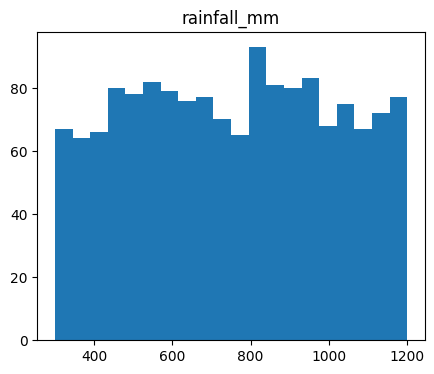

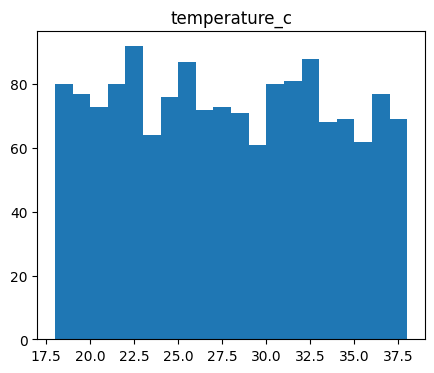

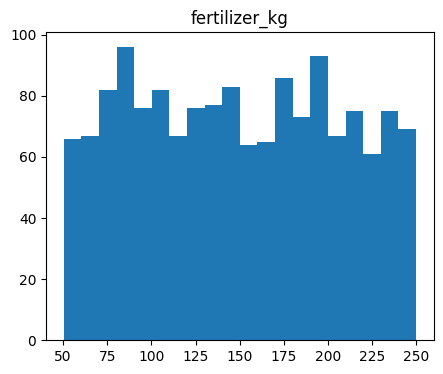

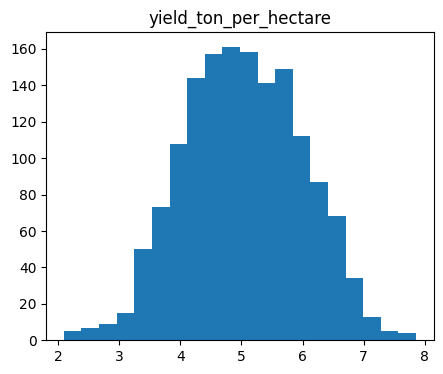

In [15]:
#Part B: Exploratory Data Analysis (EDA)

#Q4. Distribution Analysis
#Create histograms for:
# rainfall_mm
# temperature_c
# fertilizer_kg
# yield_ton_per_hectare
#Write 2–3 observations from each histogram.
cols = ['rainfall_mm','temperature_c','fertilizer_kg','yield_ton_per_hectare']

for col in cols:
    plt.figure(figsize=(5,4))
    plt.hist(df[col], bins=20)
    plt.title(col)
    plt.show()

In [ ]:
#OBSERVATION

**rainfall_mm**
Values are spread over a wide range.
Distribution is approximately uniform.
No extreme outliers.
**temperature_c**
Values mostly lie between 18°C and 38°C.
Fairly symmetric distribution.
No major outliers.
**fertilizer_kg**
Data is evenly distributed.
Moderate spread.
No skewness.
**yield_ton_per_hectare**
Nearly bell-shaped distribution.
Most values are around 5.
Very few extreme values.

In [ ]:
#Q5. Crop Type Analysis
## Find the number of records for each crop type.
## Create a count plot (bar chart) for crop_type.
## Which crop appears most frequently?

In [16]:
#Frequency
print(df['crop_type'].value_counts())

crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


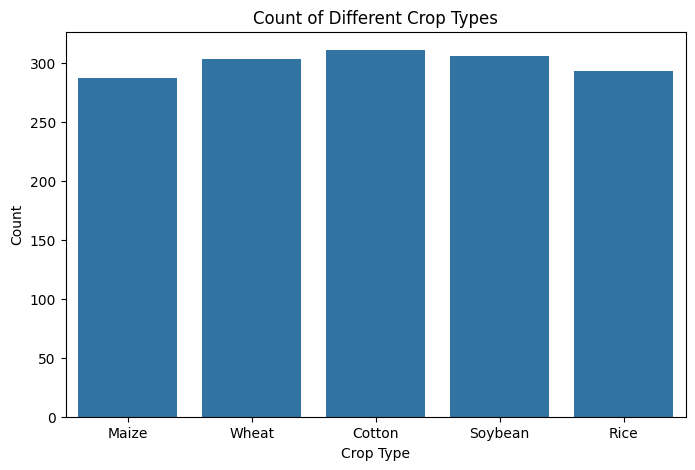

In [18]:
#Count Plot
plt.figure(figsize=(8,5))
sns.countplot(x='crop_type', data=df)

plt.title('Count of Different Crop Types')
plt.xlabel('Crop Type')
plt.ylabel('Count')
plt.show()

In [19]:
#Find the most frequent crop
most_frequent_crop = df['crop_type'].value_counts().idxmax()

print("Most frequent crop:", most_frequent_crop)

Most frequent crop: Cotton


In [ ]:
#Q6. Soil Type Analysis
# Find the frequency of each soil type.
# Create a count plot for soil_type.
# Which soil type is most common?

In [20]:
#1. Find the frequency of each soil type
# Frequency of each soil type
soil_counts = df['soil_type'].value_counts()

print(soil_counts)

soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


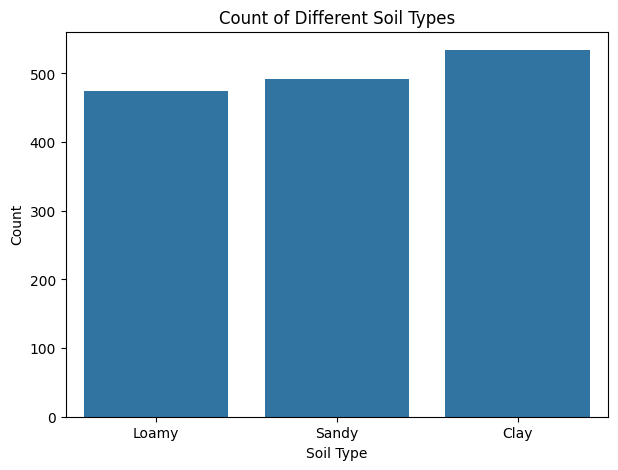

In [21]:
#Create a count plot for soil_type


plt.figure(figsize=(7,5))

sns.countplot(x='soil_type', data=df)

plt.title('Count of Different Soil Types')
plt.xlabel('Soil Type')
plt.ylabel('Count')

plt.show()

In [22]:
#the most common soil type
most_common_soil = df['soil_type'].value_counts().idxmax()

print("Most common soil type:", most_common_soil)

Most common soil type: Clay


In [ ]:
#Q7. Yield Distribution
#Create a histogram of yield_ton_per_hectare.
#Answer:
# Is the distribution approximately normal?
# Are there any noticeable outliers?


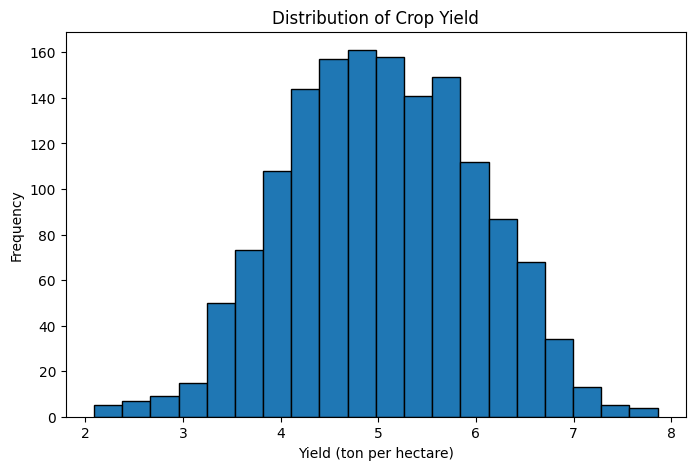

In [23]:
plt.figure(figsize=(8,5))

plt.hist(df['yield_ton_per_hectare'],
         bins=20,
         edgecolor='black')

plt.title('Distribution of Crop Yield')
plt.xlabel('Yield (ton per hectare)')
plt.ylabel('Frequency')

plt.show()

In [24]:
# Check distribution shape
print("Summary Statistics:")
print(df['yield_ton_per_hectare'].describe())


Summary Statistics:
count    1500.000000
mean        5.028793
std         0.968282
min         2.090000
25%         4.337500
50%         5.010000
75%         5.740000
max         7.860000
Name: yield_ton_per_hectare, dtype: float64


In [28]:
# Detect possible outliers using IQR method
Q1 = df['yield_ton_per_hectare'].quantile(0.25)
Q3 = df['yield_ton_per_hectare'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['yield_ton_per_hectare'] < lower_bound) |
              (df['yield_ton_per_hectare'] > upper_bound)]
print("\nNumber of outliers:", len(outliers))


Number of outliers: 3


In [ ]:
#Q8. Scatter Plot Analysis
#Create scatter plots of:
#1. rainfall_mm vs yield_ton_per_hectare
#2. fertilizer_kg vs yield_ton_per_hectare
#Based on the plots:
# Which feature appears to have a stronger relationship with yield?

<Figure size 700x500 with 0 Axes>

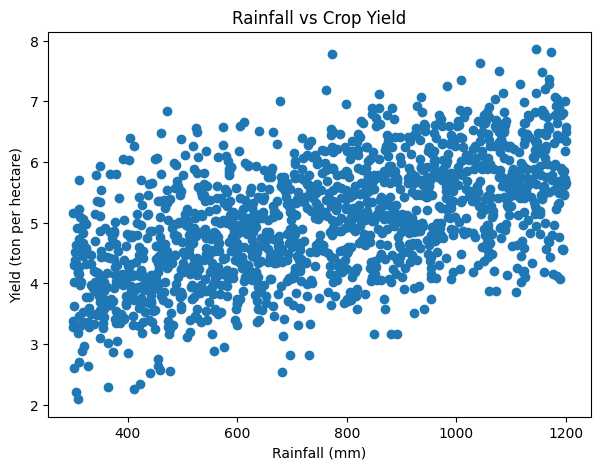

In [29]:
# Scatter plot: Rainfall vs Yield
plt.figure(figsize=(7,5))
plt.figure(figsize=(7,5))
plt.scatter(df['rainfall_mm'], df['yield_ton_per_hectare'])
plt.title('Rainfall vs Crop Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (ton per hectare)')
plt.show()

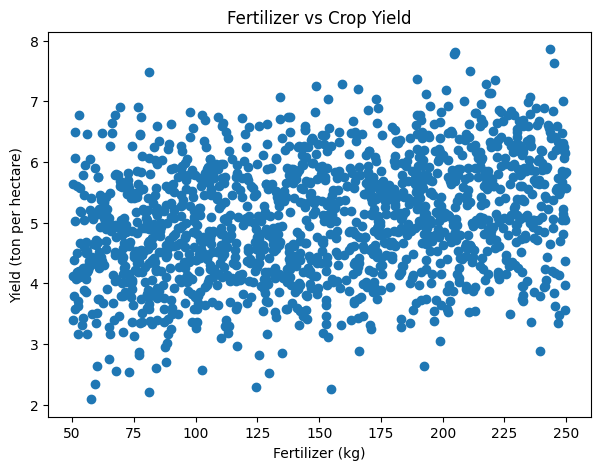

In [30]:
# Scatter plot: Fertilizer vs Yield
plt.figure(figsize=(7,5))
plt.scatter(df['fertilizer_kg'], df['yield_ton_per_hectare'])
plt.title('Fertilizer vs Crop Yield')
plt.xlabel('Fertilizer (kg)')
plt.ylabel('Yield (ton per hectare)')
plt.show()

In [31]:
# Correlation of rainfall with yield
rainfall_corr = df['rainfall_mm'].corr(df['yield_ton_per_hectare'])

# Correlation of fertilizer with yield
fertilizer_corr = df['fertilizer_kg'].corr(df['yield_ton_per_hectare'])

print("Correlation between rainfall and yield:", rainfall_corr)
print("Correlation between fertilizer and yield:", fertilizer_corr)

if abs(rainfall_corr) > abs(fertilizer_corr):
    print("Rainfall appears to have a stronger relationship with yield.")
else:
    print("Fertilizer appears to have a stronger relationship with yield.")

Correlation between rainfall and yield: 0.5537042408932247
Correlation between fertilizer and yield: 0.27804258886930494
Rainfall appears to have a stronger relationship with yield.


In [ ]:
#Q9. Correlation Analysis
# Generate a correlation matrix for numerical features.
# Create a heatmap.
# Identify the top three features most correlated with crop yield.


In [32]:
# Select only numerical columns
numerical_df = df.select_dtypes(include=['int64', 'float64'])

# Generate correlation matrix
corr_matrix = numerical_df.corr()

# Display correlation matrix
print("Correlation Matrix:")
print(corr_matrix)


Correlation Matrix:
                       rainfall_mm  temperature_c  fertilizer_kg  \
rainfall_mm               1.000000       0.026721       0.002558   
temperature_c             0.026721       1.000000       0.037468   
fertilizer_kg             0.002558       0.037468       1.000000   
irrigation_hours          0.010877       0.007114      -0.010497   
soil_ph                   0.006916       0.001513       0.010001   
yield_ton_per_hectare     0.553704      -0.022559       0.278043   

                       irrigation_hours   soil_ph  yield_ton_per_hectare  
rainfall_mm                    0.010877  0.006916               0.553704  
temperature_c                  0.007114  0.001513              -0.022559  
fertilizer_kg                 -0.010497  0.010001               0.278043  
irrigation_hours               1.000000  0.009307               0.542664  
soil_ph                        0.009307  1.000000               0.024412  
yield_ton_per_hectare          0.542664  0.024412    

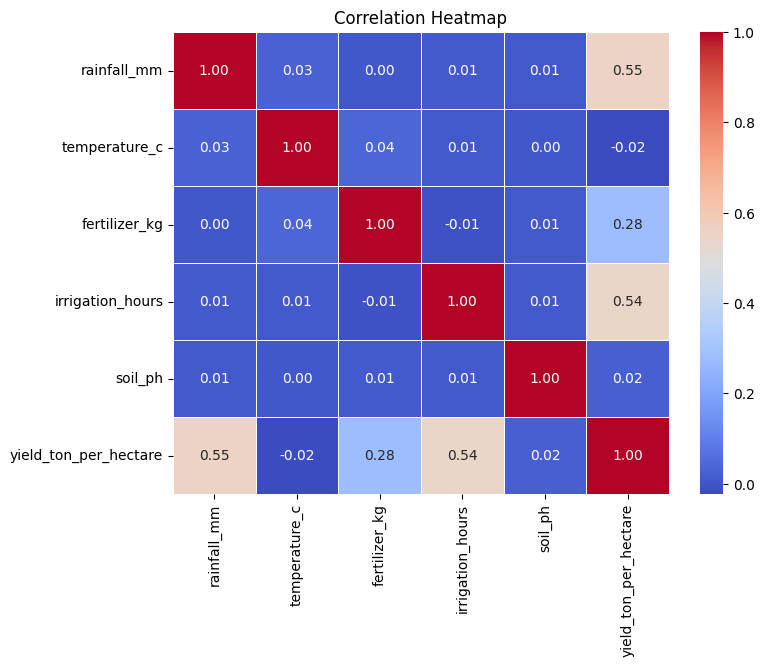

In [33]:
## Create heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            linewidths=0.5)

plt.title('Correlation Heatmap')
plt.show()

In [35]:
# Find correlation of all features with crop yield
yield_corr = corr_matrix['yield_ton_per_hectare'].sort_values(ascending=False)

print("\nCorrelation with Yield:")
print(yield_corr)
# Top three features most correlated with crop yield
top_3 = yield_corr.drop('yield_ton_per_hectare').head(3)

print("\nTop 3 Features Most Correlated with Crop Yield:")
print(top_3)


Correlation with Yield:
yield_ton_per_hectare    1.000000
rainfall_mm              0.553704
irrigation_hours         0.542664
fertilizer_kg            0.278043
soil_ph                  0.024412
temperature_c           -0.022559
Name: yield_ton_per_hectare, dtype: float64

Top 3 Features Most Correlated with Crop Yield:
rainfall_mm         0.553704
irrigation_hours    0.542664
fertilizer_kg       0.278043
Name: yield_ton_per_hectare, dtype: float64


In [ ]:
#Q10. Group-Based Analysis
#Calculate the average yield for:
# Each crop type
# Each soil type

#Which crop and soil type have the highest average yield?



In [36]:
# Average yield for each crop type
crop_yield = df.groupby('crop_type')['yield_ton_per_hectare'].mean()

print("Average Yield for Each Crop Type:")
print(crop_yield)


Average Yield for Each Crop Type:
crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64


In [37]:
# Average yield for each soil type
soil_yield = df.groupby('soil_type')['yield_ton_per_hectare'].mean()

print("\nAverage Yield for Each Soil Type:")
print(soil_yield)



Average Yield for Each Soil Type:
soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64


In [38]:
# Find crop type with highest average yield
highest_crop = crop_yield.idxmax()
highest_crop_yield = crop_yield.max()

print("\nCrop Type with Highest Average Yield:")
print(highest_crop, ":", highest_crop_yield)


Crop Type with Highest Average Yield:
Rice : 5.494744027303755


In [39]:
# Find soil type with highest average yield
highest_soil = soil_yield.idxmax()
highest_soil_yield = soil_yield.max()

print("\nSoil Type with Highest Average Yield:")
print(highest_soil, ":", highest_soil_yield)


Soil Type with Highest Average Yield:
Loamy : 5.366518987341772


In [ ]:
#Part C: Data Preparation
#Q11. Feature Encoding
#The dataset contains categorical variables.
# Identify the categorical columns.
# Convert them into numerical form using One-Hot Encoding.
# Display the first five rows of the transformed dataset.

In [40]:
# Identify the categorical columns.
# Display data types
print(df.dtypes)

# Identify categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns

print("Categorical Columns:")
print(categorical_columns)

rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object
Categorical Columns:
Index(['crop_type', 'soil_type'], dtype='object')


In [41]:
# Convert categorical columns into numerical form using One-Hot Encoding.
# Apply One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_columns)

# Display the transformed dataset
print(df_encoded.head())

   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   

   yield_ton_per_hectare  crop_type_Cotton  crop_type_Maize  crop_type_Rice  \
0                   5.92             False             True           False   
1                   6.24             False             True           False   
2                   4.77             False            False           False   
3                   4.04             False             True           False   
4                   5.17              True            False           False   

   crop_type_Soybean  crop_type_Wheat  soil_type_Clay  soil_type_Loamy  \


In [42]:
#Display the first five rows of the transformed dataset
print("First 5 rows of the transformed dataset:")
print(df_encoded.head())

First 5 rows of the transformed dataset:
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   

   yield_ton_per_hectare  crop_type_Cotton  crop_type_Maize  crop_type_Rice  \
0                   5.92             False             True           False   
1                   6.24             False             True           False   
2                   4.77             False            False           False   
3                   4.04             False             True           False   
4                   5.17              True            False           False   

   crop_type_Soybean  crop_type_W

In [ ]:
#Q12. Feature Selection
#Separate:
# Input features (X)
# Target variable (y)
#Specify which column is being used as the target variable

In [43]:
# Input features (all columns except target)
X = df_encoded.drop('yield_ton_per_hectare', axis=1)

# Target variable
y = df_encoded['yield_ton_per_hectare']

# Display X and y
print("Input Features (X):")
print(X.head())

print("\nTarget Variable (y):")
print(y.head())
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Input Features (X):
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   

   crop_type_Cotton  crop_type_Maize  crop_type_Rice  crop_type_Soybean  \
0             False             True           False              False   
1             False             True           False              False   
2             False            False           False              False   
3             False             True           False              False   
4              True            False           False              False   

   crop_type_Wheat  soil_type_Clay  soil_type_Loamy  soil_type_Sandy  
0      

In [ ]:
#Part D: Machine Learning

#Q13. Train-Test Split
#Split the dataset into:
# 80% Training Data
# 20% Testing Data
#Display the shape of:
# X_train
# X_test
# y_train
# y_test

In [44]:

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Display the shapes of the split datasets
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (1200, 13)
Shape of X_test: (300, 13)
Shape of y_train: (1200,)
Shape of y_test: (300,)


In [ ]:
#Q14. Linear Regression Model
# Train a Linear Regression model.
# Display the model coefficients and intercept.
# Which feature has the highest positive coefficient?

In [45]:
# Create the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

LinearRegression()

In [47]:

# Display the coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})
print("\nCoefficients:")
print(coefficients)


Coefficients:
              Feature  Coefficient
0         rainfall_mm     0.002035
1       temperature_c    -0.009175
2       fertilizer_kg     0.004978
3    irrigation_hours     0.198327
4             soil_ph     0.004901
5    crop_type_Cotton    -0.386623
6     crop_type_Maize    -0.147693
7      crop_type_Rice     0.477369
8   crop_type_Soybean     0.095096
9     crop_type_Wheat    -0.038149
10     soil_type_Clay     0.062653
11    soil_type_Loamy     0.365627
12    soil_type_Sandy    -0.428280


In [48]:
# Display the intercept
print("Intercept:")
print(model.intercept_)


Intercept:
1.9111026182800726


In [49]:
# feature with the highest positive coefficient
max_coef_feature = coefficients.loc[coefficients['Coefficient'].idxmax()]

print("\nFeature with Highest Positive Coefficient:")
print(max_coef_feature)


Feature with Highest Positive Coefficient:
Feature        crop_type_Rice
Coefficient          0.477369
Name: 7, dtype: object
